# Class Distribution Explorer

Reads `master_landmarks_full.csv` and shows which glosses have the most videos.
Lightweight — only loads 2 columns so runs in under a minute.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = ('/content/drive/MyDrive/Consultant/Colab_Notebooks/'
             'Obrown_Dissertation_NU_25/OBrown_DIS9300_v3/master_landmarks_full.csv')

# Only load the two columns we need -- fast even on large CSV
print('Loading...')
df = pd.read_csv(INPUT_CSV, usecols=['gloss','filename'])
print(f'Rows: {len(df):,}  |  Unique clips: {df.filename.nunique():,}  |  Unique glosses: {df.gloss.nunique()}')


Loading...
Rows: 14,098,799  |  Unique clips: 6,710  |  Unique glosses: 1867


In [9]:
# Clips per gloss (one row per unique video)
clips_per_gloss = (
    df.groupby('gloss')['filename']
    .nunique()
    .sort_values(ascending=False)
    .rename('n_clips')
)

print(f'Total glosses : {len(clips_per_gloss)}')
print(f'Total clips   : {clips_per_gloss.sum():,}')
print(f'Max clips     : {clips_per_gloss.max()}  ({clips_per_gloss.idxmax()})')
print(f'Min clips     : {clips_per_gloss.min()}  ({clips_per_gloss.idxmin()})')
print(f'Mean clips    : {clips_per_gloss.mean():.1f}')
print(f'Median clips  : {clips_per_gloss.median():.0f}')


Total glosses : 1867
Total clips   : 6,710
Max clips     : 13  (thin)
Min clips     : 1  (rehearse)
Mean clips    : 3.6
Median clips  : 3


In [10]:
TOP_N = 30
top = clips_per_gloss.head(TOP_N)

print(f'\n── Top {TOP_N} glosses by clip count ──')
print(f'{"Rank":<5} {"Gloss":<30} {"Clips":>6}')
print('-' * 44)
for rank, (gloss, n) in enumerate(top.items(), 1):
    print(f'{rank:<5} {gloss:<30} {n:>6}')



── Top 30 glosses by clip count ──
Rank  Gloss                           Clips
--------------------------------------------
1     thin                               13
2     computer                           13
3     go                                 13
4     before                             13
5     cool                               12
6     trade                              11
7     thanksgiving                       11
8     bowling                            11
9     accident                           11
10    shirt                              11
11    short                              10
12    help                               10
13    cousin                             10
14    tall                               10
15    yes                                10
16    change                             10
17    cold                               10
18    pizza                              10
19    who                                10
20    delay                            

In [11]:
# Distribution buckets
buckets = [1,2,3,4,5,10,15,20,30,50,100,9999]
labels  = ['1','2','3','4','5','6-10','11-15','16-20','21-30','31-50','51-100','100+']
print('\n── Clip count distribution ──')
print(f'{"Range":<12} {"Glosses":>8} {"% of glosses":>14}')
print('-'*36)
prev = 0
for label, upper in zip(labels, buckets):
    count = ((clips_per_gloss > prev) & (clips_per_gloss <= upper)).sum()
    pct   = count / len(clips_per_gloss) * 100
    print(f'{label:<12} {count:>8} {pct:>13.1f}%')
    prev  = upper



── Clip count distribution ──
Range         Glosses   % of glosses
------------------------------------
1                 184           9.9%
2                 315          16.9%
3                 551          29.5%
4                 401          21.5%
5                 172           9.2%
6-10              234          12.5%
11-15              10           0.5%
16-20               0           0.0%
21-30               0           0.0%
31-50               0           0.0%
51-100              0           0.0%
100+                0           0.0%


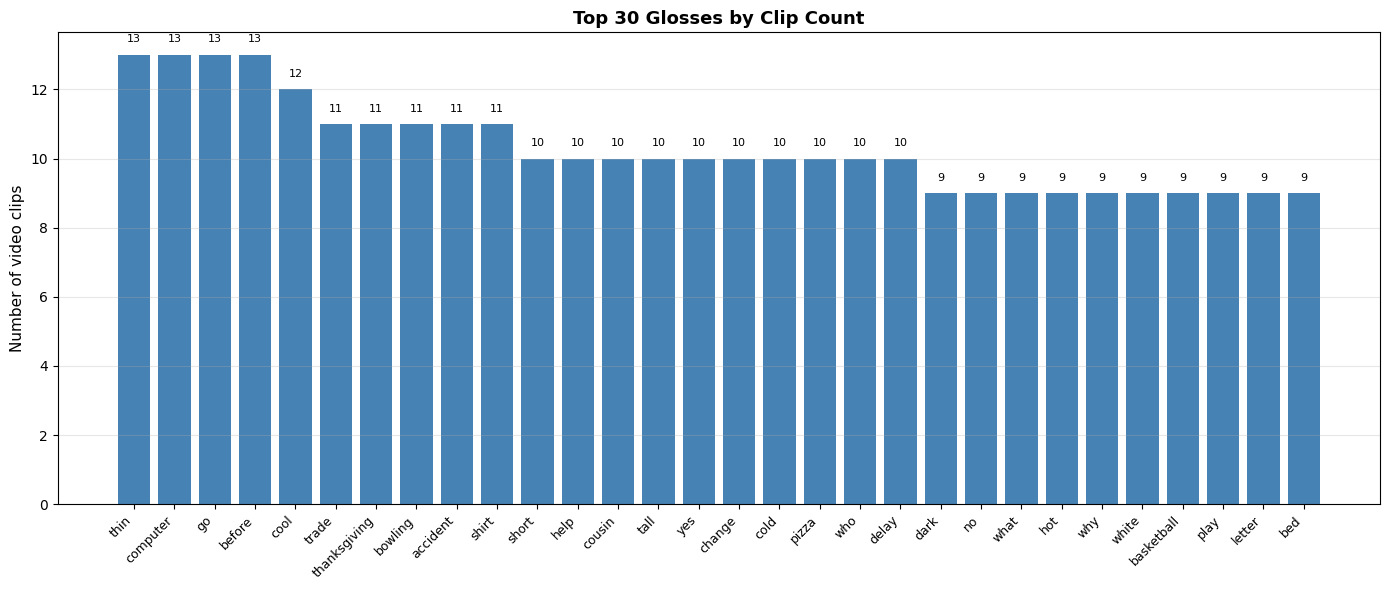

In [14]:
import os

# Bar chart -- top 30
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(top)), top.values, color='steelblue')
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of video clips', fontsize=11)
ax.set_title(f'Top {TOP_N} Glosses by Clip Count', fontweight='bold', fontsize=13)
for bar, val in zip(bars, top.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(val), ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

output_dir = '/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/analysis/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'class_distribution_top30.png'), dpi=150)
plt.show()

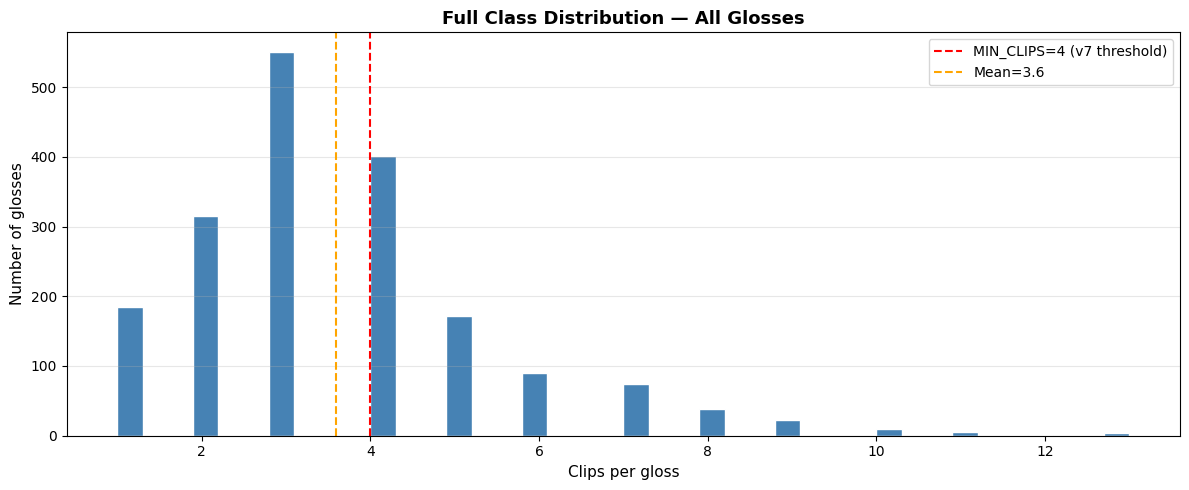

In [15]:
# Full distribution histogram
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(clips_per_gloss.values, bins=40, color='steelblue', edgecolor='white')
ax.axvline(4, color='red', ls='--', lw=1.5, label='MIN_CLIPS=4 (v7 threshold)')
ax.axvline(clips_per_gloss.mean(), color='orange', ls='--', lw=1.5,
           label=f'Mean={clips_per_gloss.mean():.1f}')
ax.set_xlabel('Clips per gloss', fontsize=11)
ax.set_ylabel('Number of glosses', fontsize=11)
ax.set_title('Full Class Distribution — All Glosses', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Consultant/Colab_Notebooks/'
            'Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/analysis/'
            'class_distribution_full.png', dpi=150)
plt.show()


In [16]:
# Save full ranked table as CSV
out_path = ('/content/drive/MyDrive/Consultant/Colab_Notebooks/'
            'Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/analysis/'
            'class_clip_counts.csv')
clips_per_gloss.reset_index().rename(
    columns={'gloss':'gloss','n_clips':'n_clips'}
).assign(rank=range(1, len(clips_per_gloss)+1)).to_csv(out_path, index=False)
print(f'Full ranked table saved to: {out_path}')
print(f'\nTop 10 most common glosses:')
print(clips_per_gloss.head(10).to_string())
print(f'\nBottom 10 (rarest glosses in dataset):')
print(clips_per_gloss.tail(10).to_string())


Full ranked table saved to: /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/analysis/class_clip_counts.csv

Top 10 most common glosses:
gloss
thin            13
computer        13
go              13
before          13
cool            12
trade           11
thanksgiving    11
bowling         11
accident        11
shirt           11

Bottom 10 (rarest glosses in dataset):
gloss
rooster     1
rough       1
attract     1
appear      1
area        1
army        1
which       1
and         1
angel       1
announce    1
